# S3Retriever Usage Guide

Two main workflows:

1. **MI values** -- retrieve precomputed mutual information scores for a single experiment or sweep across algorithms / sizes / qualities
2. **Embeddings + signals** -- retrieve matched (embedding, signal) pairs for recomputing MI with a different estimator

In [10]:
import pandas as pd
import numpy as np

from scaling_laws.s3_retriever import S3Retriever, EmbeddingSignalResult

data = S3Retriever("/home/igor/noise_scaling/data")

## 1. Retrieving MI values

### Single experiment

In [11]:
mi = data.load_mutual_information(
    "merfish", num_cells=7113, quality=1.0,
    algorithm="Geneformer", signal="ng_idx", seed=42,
)
print(f"MI = {mi:.4f} nats")

MI = 0.9799 nats


### Sweep: compare algorithms for a fixed (dataset, size, quality)

In [12]:
rows = []
for algo in data.list_algorithms():
    for signal in data.list_signals("merfish"):
        try:
            mi = data.load_mutual_information(
                "merfish", num_cells=7113, quality=1.0,
                algorithm=algo, signal=signal, seed=42,
            )
            rows.append({"algorithm": algo, "signal": signal, "mi": mi})
        except FileNotFoundError:
            pass

pd.DataFrame(rows).pivot(index="algorithm", columns="signal", values="mi")

signal,cur_idx,ng_idx
algorithm,,
Geneformer,NaN,0.97994
PCA,1.59215,1.52864
RandomProjection,0.49250,0.50802
SCVI,1.81980,1.76563
State,-0.00224,0.03583


### Bulk sweep: all sizes and qualities for a dataset

`collect_all_mi_results` returns a DataFrame over all (size, quality, algorithm, signal, seed) combinations.

In [13]:
mi_df = data.collect_all_mi_results("merfish", algorithms=["PCA", "Geneformer"])
print(f"{len(mi_df)} MI results collected")
mi_df.head(10)

1196 MI results collected


,dataset,num_cells,quality,algorithm,signal,seed,mi
0,merfish,100,0.027248,PCA,cur_idx,42,0.09041
1,merfish,100,0.027248,PCA,cur_idx,1404,0.10975
2,merfish,100,0.027248,PCA,cur_idx,2303,0.12360
3,merfish,100,0.027248,PCA,cur_idx,2701,0.11437
4,merfish,100,0.027248,PCA,ng_idx,42,0.15587
5,merfish,100,0.027248,PCA,ng_idx,1404,0.13932
6,merfish,100,0.027248,PCA,ng_idx,2303,0.12343
7,merfish,100,0.027248,PCA,ng_idx,2701,0.15609
8,merfish,100,0.027248,Geneformer,ng_idx,42,0.09424
9,merfish,100,0.027248,Geneformer,ng_idx,1404,0.15916


## 2. Retrieving matched embeddings + signal data

For recomputing MI with a different estimator you need both the embedding matrix and the corresponding signal vector/matrix. Rows are aligned: row *i* in the embedding corresponds to row *i* in the signal DataFrame.

### Single experiment

In [14]:
# Load embedding and its matched signal separately
emb = data.load_embeddings("merfish", num_cells=7113, quality=1.0, algorithm="PCA")
sig = data.load_test_signal("merfish", quality=1.0, signal="ng_idx", algorithm="PCA")

print(f"Embedding shape: {emb.shape}")
print(f"Signal shape:    {sig.shape}")
print(f"Signal columns:  {list(sig.columns)}")
print()
print("Embedding (first 3 rows):")
display(emb.head(3))
print("Signal (first 3 rows):")
display(sig.head(3))

Embedding shape: (78329, 15)
Signal shape:    (78329, 2)
Signal columns:  ['cur_idx', 'ng_idx']

Embedding (first 3 rows):


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,,,,,,,,,,,,,,,
8.991231,4.911483,-9.149575,2.504036,1.762032,0.422403,-1.847038,4.897217,0.803403,-1.827472,-3.950979,5.500891,-5.074595,2.624233,1.366982,-0.696142
19.574760,11.088132,-9.146174,-1.317844,1.428151,4.082576,-0.430419,3.601266,1.479459,-4.022424,-3.701388,6.902003,-2.108080,2.677644,0.310113,-0.992269
10.214234,11.076890,-16.386136,8.810896,-1.325087,-0.628655,1.947577,-0.326313,1.424835,-1.111365,1.336945,0.518430,-2.012646,-2.811125,0.388442,-1.515401


Signal (first 3 rows):


,cur_idx,ng_idx
0,110883424764611924400221639916314253469,78912778139286602007597933545624587149
1,135188247894899244046039873973964001182,164766962839370328502017156371562646881
2,164766962839370328502017156371562646881,110883424764611924400221639916314253469


### Sweep with `iter_embeddings_with_signals`

The iterator yields an `EmbeddingSignalResult` dataclass for every (dataset, size, quality, algorithm, signal) combination. Missing files are silently skipped. The tqdm bar shows the current configuration being loaded.

In [15]:
# Compare all algorithms on merfish at a single (size, quality),
# getting matched embedding + signal for each.
for result in data.iter_embeddings_with_signals(
    datasets=["merfish"],
    sizes={"merfish": [7113]},
    qualities={"merfish": [1.0]},
):
    print(
        f"{result.algorithm:20s} signal={result.signal:<10s}  "
        f"emb={str(result.embedding.shape):<16s}  "
        f"signal_data={str(result.signal_data.shape)}"
    )

merfish | n=7113 | q=1.0 | SCVI | cur_idx:  20%|██        | 2/10 [00:08<00:32,  4.09s/config]      

Geneformer           signal=ng_idx      emb=(78329, 255)      signal_data=(78329, 2)


merfish | n=7113 | q=1.0 | SCVI | ng_idx:  30%|███       | 3/10 [00:08<00:16,  2.33s/config] 

SCVI                 signal=cur_idx     emb=(78329, 15)       signal_data=(78329, 2)


merfish | n=7113 | q=1.0 | State | cur_idx:  40%|████      | 4/10 [00:08<00:08,  1.50s/config]

...

PCA                  signal=ng_idx      emb=(78329, 15)       signal_data=(78329, 2)


merfish | n=7113 | q=1.0 | RandomProjection | ng_idx:  90%|█████████ | 9/10 [00:15<00:00,  1.07config/s] 

RandomProjection     signal=cur_idx     emb=(78329, 15)       signal_data=(78329, 2)


merfish | n=7113 | q=1.0 | RandomProjection | ng_idx: 100%|██████████| 10/10 [00:15<00:00,  1.57s/config]

RandomProjection     signal=ng_idx      emb=(78329, 15)       signal_data=(78329, 2)


### Filtered sweep across sizes

Filter by algorithm and signal to get one (embedding, signal) pair per training size -- useful for plotting MI vs. dataset size with a new estimator.

In [16]:
for result in data.iter_embeddings_with_signals(
    datasets=["merfish"],
    qualities={"merfish": [1.0]},
    algorithms=["Geneformer"],
    signals={"merfish": ["ng_idx"]},
):
    X = result.embedding.values         # (n_test_cells, embedding_dim)
    Y = result.signal_data              # (n_test_cells, ...)

    # Plug X, Y into your MI estimator here, e.g.:
    #   mi = my_estimator(X, Y)

    print(
        f"n={result.num_cells:<8d}  "
        f"X {str(X.shape):<16s}  "
        f"Y {str(Y.shape)}"
    )

merfish | n=203 | q=1.0 | Geneformer | ng_idx:  10%|█         | 1/10 [00:03<00:35,  3.99s/config]

n=100       X (78329, 255)      Y (78329, 2)


merfish | n=414 | q=1.0 | Geneformer | ng_idx:  20%|██        | 2/10 [00:07<00:31,  3.99s/config]

n=203       X (78329, 255)      Y (78329, 2)


merfish | n=843 | q=1.0 | Geneformer | ng_idx:  30%|███       | 3/10 [00:12<00:28,  4.01s/config]

...

n=14480     X (78329, 255)      Y (78329, 2)


merfish | n=60000 | q=1.0 | Geneformer | ng_idx:  90%|█████████ | 9/10 [00:36<00:04,  4.10s/config]

n=29475     X (78329, 255)      Y (78329, 2)


merfish | n=60000 | q=1.0 | Geneformer | ng_idx: 100%|██████████| 10/10 [00:40<00:00,  4.07s/config]

n=60000     X (78329, 255)      Y (78329, 2)


## 3. UMAP of embeddings colored by biological signals

Select 3 different (dataset, algorithm, signal) combinations, retrieve embeddings + signals, and visualize with UMAP.

In [17]:
import matplotlib.pyplot as plt
import umap

configs = [
    {"dataset": "merfish",  "num_cells": 60000,  "quality": 1.0, "algorithm": "Geneformer", "signal": "ng_idx"},
    {"dataset": "PBMC",     "num_cells": 100000, "quality": 1.0, "algorithm": "PCA",        "signal": "celltype.l3"},
    {"dataset": "larry",    "num_cells": 100000, "quality": 1.0, "algorithm": "SCVI",       "signal": "clone"},
]

SUBSAMPLE = 5000

results = []
for cfg in configs:
    emb = data.load_embeddings(cfg["dataset"], cfg["num_cells"], cfg["quality"], cfg["algorithm"])
    sig = data.load_test_signal(cfg["dataset"], cfg["quality"], cfg["signal"], cfg["algorithm"])

    # subsample to 5k points for fast UMAP
    if len(emb) > SUBSAMPLE:
        idx = np.random.RandomState(42).choice(len(emb), SUBSAMPLE, replace=False)
        emb = emb.iloc[idx]
        sig = sig.iloc[idx]

    label = f"{cfg['dataset']} / {cfg['algorithm']} / {cfg['signal']}"
    print(f"{label}  —  emb {emb.shape}, signal {sig.shape}")
    results.append({"cfg": cfg, "emb": emb, "sig": sig, "label": label})

merfish / Geneformer / ng_idx  —  emb (5000, 255), signal (5000, 2)
PBMC / PCA / celltype.l3  —  emb (5000, 15), signal (5000, 1)
larry / SCVI / clone  —  emb (5000, 15), signal (5000, 3)


/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_960175/1296501770.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = y.dtype == object or pd.api.types.is_categorical_dtype(y) or len(np.unique(y)) < 50


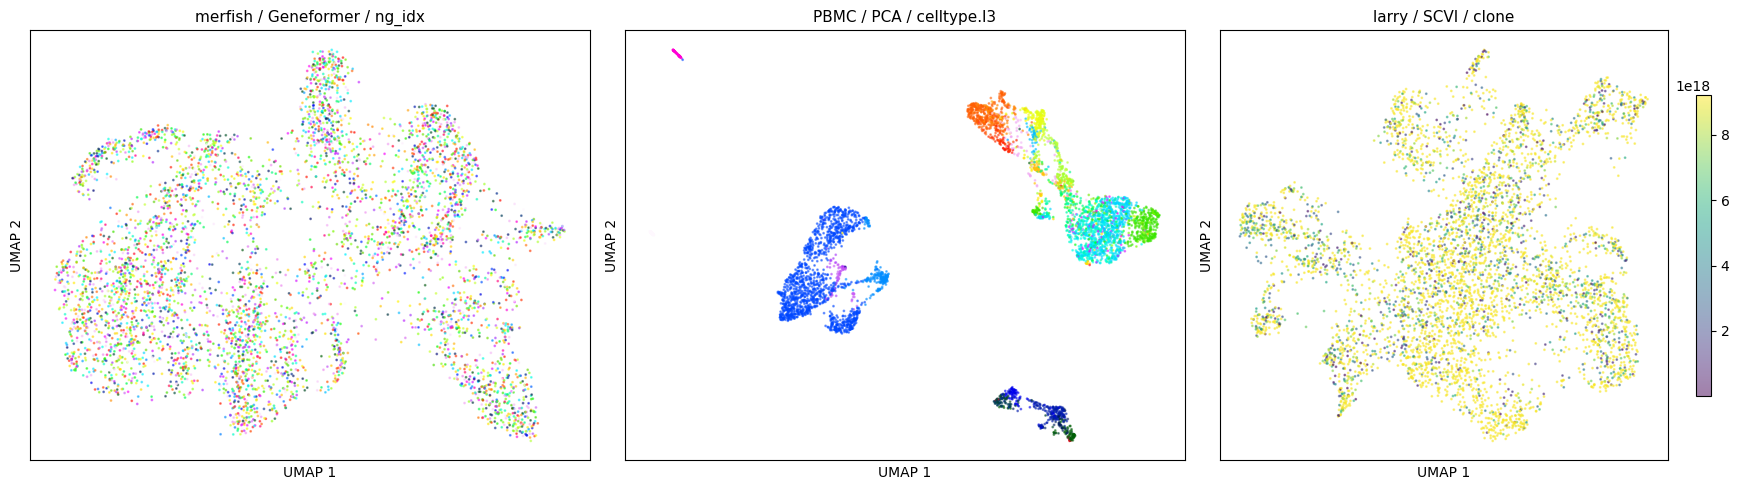

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, r in zip(axes, results):
    X = r["emb"].values
    sig_col = r["cfg"]["signal"]
    sig_df = r["sig"]

    # use the signal column if present, otherwise take the first column
    if sig_col in sig_df.columns:
        y = sig_df[sig_col].values
    else:
        y = sig_df.iloc[:, 0].values

    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
    coords = reducer.fit_transform(X)

    # categorical vs continuous coloring
    is_categorical = y.dtype == object or pd.api.types.is_categorical_dtype(y) or len(np.unique(y)) < 50
    if is_categorical:
        categories = np.unique(y)
        cmap = plt.cm.tab20 if len(categories) <= 20 else plt.cm.gist_ncar
        cat_to_int = {c: i for i, c in enumerate(categories)}
        colors = np.array([cat_to_int[v] for v in y])
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap=cmap,
                        s=1, alpha=0.5, rasterized=True)
    else:
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=y.astype(float), cmap="viridis",
                        s=1, alpha=0.5, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.7)

    ax.set_title(r["label"], fontsize=11)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()